# modelo actual de clones de codigo en python

en este notebook construimos nuestro modelo actual con dos capas

- capa 1 lexica con tf-idf similitudes y baker
- capa 2 estructural con ast reducido
- clasificacion con random forest


## 1) configuracion e imports


In [81]:
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Iterable
import io
import random
import re
import tokenize
import ast
import keyword

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import sparse
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from IPython.display import display




In [82]:
SEED = 42

ESTRATEGIA_BALANCEO = 'undersample'  # none undersample oversample

MIN_MATCH_LEN_BAKER = 3

AST_VARIANT_OFICIAL = 'reduced'
MODELO_CLASIFICADOR = 'random_forest'

random.seed(SEED)
np.random.seed(SEED)

RUTA_BASE = Path.cwd()
if (RUTA_BASE / 'clone_pairs_dataset_metadata.csv').exists():
    RUTA_DATASET = RUTA_BASE
else:
    RUTA_DATASET = RUTA_BASE / 'DataBaseProject'

RUTA_METADATA = RUTA_DATASET / 'clone_pairs_dataset_metadata.csv'
RUTA_PARES = RUTA_DATASET / 'pares_clones'

print('RUTA_DATASET:', RUTA_DATASET)
print('RUTA_METADATA:', RUTA_METADATA)
print('RUTA_PARES:', RUTA_PARES)
print('ESTRATEGIA_BALANCEO:', ESTRATEGIA_BALANCEO)
print('MIN_MATCH_LEN_BAKER:', MIN_MATCH_LEN_BAKER)
print('AST_VARIANT_OFICIAL:', AST_VARIANT_OFICIAL)
print('MODELO_CLASIFICADOR:', MODELO_CLASIFICADOR)


RUTA_DATASET: c:\Users\estef\Downloads\code-clone-detector\DataBaseProject
RUTA_METADATA: c:\Users\estef\Downloads\code-clone-detector\DataBaseProject\clone_pairs_dataset_metadata.csv
RUTA_PARES: c:\Users\estef\Downloads\code-clone-detector\DataBaseProject\pares_clones
ESTRATEGIA_BALANCEO: undersample
MIN_MATCH_LEN_BAKER: 3
AST_VARIANT_OFICIAL: reduced
MODELO_CLASIFICADOR: random_forest


## 2) dataset y reconstruccion de snippets


In [83]:
COLUMNAS_METADATA = [
    'is_clone', 'clone_type', 'source_group', 'filename', 'file_path',
    'problem_id', 'snippet_index_a', 'snippet_index_b'
]

PATRON_MARCADOR_LENGUAJE = re.compile(r'^\s*(python|java|javascript|c\+\+|cpp|ruby|go)\s*$', flags=re.IGNORECASE | re.MULTILINE)
PATRON_SEPARADOR_SNIPPETS = re.compile(r'\n\s*\n\s*\n+')
PATRON_ESPACIOS = re.compile(r'[ \t]+')
PATRON_SALTOS = re.compile(r'\n{3,}')


@dataclass
class ResultadoSplit:
    train_idx: pd.Index
    val_idx: pd.Index
    test_idx: pd.Index


def cargar_metadata(ruta_csv: Path) -> pd.DataFrame:
    # aqui cargamos la metadata del csv
    return pd.read_csv(ruta_csv)


def limpiar_metadata(df: pd.DataFrame) -> pd.DataFrame:
    # aqui limpiamos filas incompletas y normalizamos columnas
    out = df.copy()
    out = out[COLUMNAS_METADATA].copy()
    out['is_clone'] = pd.to_numeric(out['is_clone'], errors='coerce')
    out['problem_id'] = pd.to_numeric(out['problem_id'], errors='coerce')
    out['snippet_index_a'] = pd.to_numeric(out['snippet_index_a'], errors='coerce')
    out['snippet_index_b'] = pd.to_numeric(out['snippet_index_b'], errors='coerce')
    out = out.dropna(subset=['is_clone', 'clone_type', 'file_path', 'problem_id', 'snippet_index_a', 'snippet_index_b']).copy()
    out['is_clone'] = out['is_clone'].astype(int)
    out['problem_id'] = out['problem_id'].astype(int)
    out['snippet_index_a'] = out['snippet_index_a'].astype(int)
    out['snippet_index_b'] = out['snippet_index_b'].astype(int)

    out = out[out['is_clone'] == 1].copy()
    return out


def separar_snippets(texto_archivo: str) -> list[str]:
    # aqui separamos los snippets de cada archivo de pares
    texto = texto_archivo.replace('\r\n', '\n').replace('\r', '\n').strip()
    if not texto:
        return []

    bloques = [b.strip() for b in PATRON_MARCADOR_LENGUAJE.split(texto) if b.strip()]
    snippets = []
    for bloque in bloques:
        partes = [p.strip() for p in PATRON_SEPARADOR_SNIPPETS.split(bloque) if p.strip()]
        if len(partes) > 1:
            snippets.extend(partes)
        else:
            snippets.append(bloque)

    if len(snippets) < 2:
        fallback = [p.strip() for p in PATRON_SEPARADOR_SNIPPETS.split(texto) if p.strip()]
        if len(fallback) > len(snippets):
            snippets = fallback
    return snippets


def normalizar_ruta_relativa(ruta: str) -> Path:
    # aqui normalizamos rutas para poder leer archivos
    return Path(str(ruta).replace('\\', '/'))


def reconstruir_pares(df_metadata: pd.DataFrame, ruta_dataset: Path) -> tuple[pd.DataFrame, pd.DataFrame, dict[str, Any]]:
    # aqui reconstruimos cada par de codigo desde la metadata
    filas_ok = []
    filas_drop = []

    cache_snippets = {}

    for fila in df_metadata.itertuples(index=False):
        ruta_rel = normalizar_ruta_relativa(str(fila.file_path))
        ruta_abs = ruta_dataset / ruta_rel
        clave = str(ruta_rel).lower()

        if clave not in cache_snippets:
            if not ruta_abs.exists():
                cache_snippets[clave] = None
            else:
                texto = ruta_abs.read_text(encoding='utf-8', errors='replace')
                cache_snippets[clave] = separar_snippets(texto)

        snippets = cache_snippets[clave]
        if snippets is None:
            filas_drop.append({**fila._asdict(), 'drop_reason': 'file_not_found'})
            continue

        idx_a = int(fila.snippet_index_a)
        idx_b = int(fila.snippet_index_b)

        if idx_a < 0 or idx_b < 0:
            filas_drop.append({**fila._asdict(), 'drop_reason': 'negative_snippet_index'})
            continue

        if idx_a >= len(snippets) or idx_b >= len(snippets):
            filas_drop.append({**fila._asdict(), 'drop_reason': 'snippet_index_out_of_range'})
            continue

        filas_ok.append({
            **fila._asdict(),
            'resolved_path': str(ruta_abs),
            'snippet_count': len(snippets),
            'code_a': snippets[idx_a],
            'code_b': snippets[idx_b],
        })

    df_ok = pd.DataFrame(filas_ok)
    df_drop = pd.DataFrame(filas_drop)
    resumen = {
        'metadata_rows': int(len(df_metadata)),
        'reconstructed_rows': int(len(df_ok)),
        'dropped_rows': int(len(df_drop)),
    }
    return df_ok, df_drop, resumen


In [84]:
datos_metadata = cargar_metadata(RUTA_METADATA)
datos_metadata_limpios = limpiar_metadata(datos_metadata)
datos_reconstruidos, datos_descartados, resumen_reconstruccion = reconstruir_pares(datos_metadata_limpios, RUTA_DATASET)

print('Filas metadata:', len(datos_metadata))
print('Filas limpias (solo clones):', len(datos_metadata_limpios))
print('Resumen reconstruccion:', resumen_reconstruccion)

if len(datos_descartados) > 0:
    print('Descartados por motivo:')
    print(datos_descartados['drop_reason'].value_counts())


Filas metadata: 8400
Filas limpias (solo clones): 8400
Resumen reconstruccion: {'metadata_rows': 8400, 'reconstructed_rows': 8400, 'dropped_rows': 0}


## 3) preprocesamiento


In [85]:
def quitar_comentarios(codigo: str) -> str:
    # aqui quitamos comentarios del codigo para reducir ruido
    if not codigo.strip():
        return codigo
    try:
        salida = []
        lector = io.StringIO(codigo).readline
        for tok in tokenize.generate_tokens(lector):
            if tok.type == tokenize.COMMENT:
                continue
            salida.append(tok)
        return tokenize.untokenize(salida)
    except (tokenize.TokenError, IndentationError):
        return codigo


def normalizar_espacios(codigo: str) -> str:
    # aqui normalizamos espacios para dejar texto mas estable
    lineas = []
    for linea in codigo.splitlines():
        compacta = PATRON_ESPACIOS.sub(' ', linea).rstrip()
        lineas.append(compacta)
    normalizado = '\n'.join(lineas).strip()
    normalizado = PATRON_SALTOS.sub('\n\n', normalizado)
    return normalizado


def preprocesar_codigo(codigo: str) -> str:
    # aqui aplicamos el preprocesamiento completo del codigo
    return normalizar_espacios(quitar_comentarios(codigo))


def tokenizar_python(codigo: str) -> list[str]:
    # aqui tokenizamos el codigo usando tokenize de python
    if not codigo.strip():
        return []
    try:
        tokens = []
        lector = io.StringIO(codigo).readline
        excluir = {tokenize.ENCODING, tokenize.ENDMARKER, tokenize.NL, tokenize.NEWLINE, tokenize.INDENT, tokenize.DEDENT, tokenize.COMMENT}
        for tok in tokenize.generate_tokens(lector):
            if tok.type in excluir:
                continue
            t = tok.string.strip()
            if t:
                tokens.append(t)
        return tokens
    except (tokenize.TokenError, IndentationError):
        return re.findall(r'[A-Za-z_]\w*|\d+|==|!=|<=|>=|[-+*/%=<>()[\]{}.,:;]', codigo)


def preparar_campos_par(df: pd.DataFrame) -> pd.DataFrame:
    # aqui preparamos los campos limpios y tokenizados por par
    out = df.copy()
    code_a_clean = [preprocesar_codigo(x) for x in out['code_a'].astype(str)]
    code_b_clean = [preprocesar_codigo(x) for x in out['code_b'].astype(str)]
    tokens_a = [tokenizar_python(x) for x in code_a_clean]
    tokens_b = [tokenizar_python(x) for x in code_b_clean]

    out['code_a_clean'] = code_a_clean
    out['code_b_clean'] = code_b_clean
    out['tokens_a'] = tokens_a
    out['tokens_b'] = tokens_b
    out['token_text_a'] = [' '.join(t) for t in tokens_a]
    out['token_text_b'] = [' '.join(t) for t in tokens_b]
    return out


datos_preparados = preparar_campos_par(datos_reconstruidos)
print('Filas listas para modelado:', len(datos_preparados))


Filas listas para modelado: 8400


## 4) capa 1 lexica del modelo


In [86]:


def similitud_jaccard(tokens_a: Iterable[str], tokens_b: Iterable[str]) -> float:
    # aqui calculamos jaccard entre tokens unicos
    set_a = set(tokens_a); set_b = set(tokens_b)
    if not set_a and not set_b:
        return 1.0
    union = set_a | set_b
    if not union:
        return 0.0
    return float(len(set_a & set_b) / len(union))


def similitud_dice(tokens_a: Iterable[str], tokens_b: Iterable[str]) -> float:
    # aqui calculamos dice entre tokens unicos
    set_a = set(tokens_a); set_b = set(tokens_b)
    if not set_a and not set_b:
        return 1.0
    denom = len(set_a) + len(set_b)
    if denom == 0:
        return 0.0
    return float(2.0 * len(set_a & set_b) / denom)


def ratio_overlap(tokens_a: Iterable[str], tokens_b: Iterable[str]) -> float:
    # aqui calculamos overlap con respecto al conjunto menor
    set_a = set(tokens_a); set_b = set(tokens_b)
    if not set_a and not set_b:
        return 1.0
    min_size = min(len(set_a), len(set_b))
    if min_size == 0:
        return 0.0
    return float(len(set_a & set_b) / min_size)


def ajustar_tfidf(df_train: pd.DataFrame) -> TfidfVectorizer:
    # aqui ajustamos tfidf solo con train para evitar fuga
    corpus = pd.concat([df_train['token_text_a'], df_train['token_text_b']], axis=0)
    vector = TfidfVectorizer(tokenizer=str.split, preprocessor=None, token_pattern=None, lowercase=False, ngram_range=(1, 2), min_df=1)
    vector.fit(corpus)
    return vector


def coseno_fila_a_fila(mat_a: sparse.spmatrix, mat_b: sparse.spmatrix) -> np.ndarray:
    # aqui calculamos coseno por fila entre matrices tfidf
    producto = np.asarray(mat_a.multiply(mat_b).sum(axis=1)).ravel()
    norma_a = np.sqrt(np.asarray(mat_a.multiply(mat_a).sum(axis=1)).ravel())
    norma_b = np.sqrt(np.asarray(mat_b.multiply(mat_b).sum(axis=1)).ravel())
    denom = norma_a * norma_b
    denom[denom == 0.0] = 1e-12
    return producto / denom


def construir_features_lexicas_base(df: pd.DataFrame, vector: TfidfVectorizer) -> pd.DataFrame:
    # aqui construimos las features lexicas base
    mat_a = vector.transform(df['token_text_a'])
    mat_b = vector.transform(df['token_text_b'])
    coseno = coseno_fila_a_fila(mat_a, mat_b)

    chars_a = df['code_a_clean'].str.len().astype(float)
    chars_b = df['code_b_clean'].str.len().astype(float)
    lineas_a = df['code_a_clean'].str.count('\n').astype(float) + 1.0
    lineas_b = df['code_b_clean'].str.count('\n').astype(float) + 1.0
    tokens_a = df['tokens_a'].apply(len).astype(float)
    tokens_b = df['tokens_b'].apply(len).astype(float)

    jaccard = [similitud_jaccard(a, b) for a, b in zip(df['tokens_a'], df['tokens_b'])]
    dice = [similitud_dice(a, b) for a, b in zip(df['tokens_a'], df['tokens_b'])]
    overlap = [ratio_overlap(a, b) for a, b in zip(df['tokens_a'], df['tokens_b'])]

    return pd.DataFrame({
        'cosine_tfidf': coseno,
        'jaccard_tokens': jaccard,
        'dice_tokens': dice,
        'overlap_unique_tokens': overlap,
        'char_len_a': chars_a,
        'char_len_b': chars_b,
        'char_len_diff': (chars_a - chars_b).abs(),
        'line_count_a': lineas_a,
        'line_count_b': lineas_b,
        'line_count_diff': (lineas_a - lineas_b).abs(),
        'token_count_a': tokens_a,
        'token_count_b': tokens_b,
        'token_count_diff': (tokens_a - tokens_b).abs(),
    }, index=df.index)




def baker_tokenizar_generalizar(codigo: str) -> list[str]:
    # aqui tokenizamos y generalizamos para baker
    if not codigo.strip():
        return []
    out = []
    try:
        lector = io.StringIO(codigo).readline
        for tok in tokenize.generate_tokens(lector):
            if tok.type in {tokenize.ENCODING, tokenize.ENDMARKER, tokenize.NL, tokenize.NEWLINE, tokenize.INDENT, tokenize.DEDENT, tokenize.COMMENT}:
                continue
            s = tok.string.strip()
            if not s:
                continue
            if tok.type == tokenize.NAME:
                out.append(s if keyword.iskeyword(s) else 'ID')
            elif tok.type == tokenize.NUMBER:
                out.append('NUM')
            elif tok.type == tokenize.STRING:
                out.append('STR')
            else:
                out.append(s)
    except (tokenize.TokenError, IndentationError):
        return []
    return out


def baker_suffix_array(seq: list[str]) -> list[int]:
    # aqui construimos el suffix array para baker
    n = len(seq)
    if n <= 1:
        return list(range(n))
    uniq = {t: i for i, t in enumerate(sorted(set(seq)))}
    rank = [uniq[t] for t in seq]
    sa = list(range(n))
    tmp = [0] * n
    k = 1
    while True:
        sa.sort(key=lambda i: (rank[i], rank[i + k] if i + k < n else -1))
        clases = 0
        tmp[sa[0]] = 0
        for i in range(1, n):
            p, c = sa[i - 1], sa[i]
            kp = (rank[p], rank[p + k] if p + k < n else -1)
            kc = (rank[c], rank[c + k] if c + k < n else -1)
            if kp != kc:
                clases += 1
            tmp[c] = clases
        rank = tmp[:]
        if clases == n - 1:
            break
        k <<= 1
    return sa


def baker_lcp_array(seq: list[str], sa: list[int]) -> list[int]:
    # aqui calculamos el arreglo lcp para baker
    n = len(seq)
    if n == 0:
        return []
    rank = [0] * n
    for i, s in enumerate(sa):
        rank[s] = i
    lcp = [0] * n
    k = 0
    for i in range(n):
        ri = rank[i]
        if ri == 0:
            k = 0
            continue
        j = sa[ri - 1]
        while i + k < n and j + k < n and seq[i + k] == seq[j + k]:
            k += 1
        lcp[ri] = k
        if k > 0:
            k -= 1
    return lcp


def baker_features_par(codigo_a: str, codigo_b: str, min_match_len: int = 3) -> dict[str, float]:
    # aqui calculamos las features baker para un par
    ta = baker_tokenizar_generalizar(codigo_a)
    tb = baker_tokenizar_generalizar(codigo_b)
    la, lb = len(ta), len(tb)

    if la == 0 or lb == 0:
        return {
            'baker_similarity': 0.0,
            'baker_common_length': 0.0,
            'baker_longest_match': 0.0,
            'baker_num_matches': 0.0,
            'baker_coverage_a': 0.0,
            'baker_coverage_b': 0.0,
        }

    sep1 = '__A_END__'
    sep2 = '__B_END__'
    while sep1 in ta or sep1 in tb:
        sep1 += '_X'
    while sep2 in ta or sep2 in tb or sep2 == sep1:
        sep2 += '_Y'

    concat = ta + [sep1] + tb + [sep2]
    sa = baker_suffix_array(concat)
    lcp = baker_lcp_array(concat, sa)

    def origen(idx: int) -> int:
        # aqui marcamos de que snippet viene cada indice
        if idx < la:
            return 0
        if idx == la or idx == la + 1 + lb:
            return -1
        if la < idx < la + 1 + lb:
            return 1
        return -1

    candidatos = []
    for i in range(1, len(sa)):
        common = lcp[i]
        if common < min_match_len:
            continue
        s1, s2 = sa[i - 1], sa[i]
        o1, o2 = origen(s1), origen(s2)
        if o1 == -1 or o2 == -1 or o1 == o2:
            continue

        if o1 == 0:
            a0 = s1
            b0 = s2 - (la + 1)
        else:
            a0 = s2
            b0 = s1 - (la + 1)

        if a0 < 0 or b0 < 0:
            continue
        common = min(common, la - a0, lb - b0)
        if common >= min_match_len:
            candidatos.append((a0, b0, common))

    candidatos = sorted(set(candidatos), key=lambda x: (-x[2], x[0], x[1]))
    cover_a = [False] * la
    cover_b = [False] * lb
    seleccion = []
    for a0, b0, ln in candidatos:
        ra = range(a0, a0 + ln)
        rb = range(b0, b0 + ln)
        if any(cover_a[i] for i in ra) or any(cover_b[j] for j in rb):
            continue
        seleccion.append((a0, b0, ln))
        for i in ra:
            cover_a[i] = True
        for j in rb:
            cover_b[j] = True

    common_len = float(sum(ln for _, _, ln in seleccion))
    longest = float(max((ln for _, _, ln in seleccion), default=0))
    nmatch = float(len(seleccion))
    cov_a = common_len / float(la) if la > 0 else 0.0
    cov_b = common_len / float(lb) if lb > 0 else 0.0
    sim = common_len / float(min(la, lb)) if min(la, lb) > 0 else 0.0

    return {
        'baker_similarity': sim,
        'baker_common_length': common_len,
        'baker_longest_match': longest,
        'baker_num_matches': nmatch,
        'baker_coverage_a': cov_a,
        'baker_coverage_b': cov_b,
    }


def construir_features_baker(df: pd.DataFrame, min_match_len: int = 3) -> pd.DataFrame:
    # aqui construimos las features baker para todo el dataset
    rows = [
        baker_features_par(a, b, min_match_len=min_match_len)
        for a, b in zip(df['code_a_clean'], df['code_b_clean'])
    ]
    return pd.DataFrame(rows, index=df.index)


def construir_features_modelo(df: pd.DataFrame, vector: TfidfVectorizer, min_match_len: int = 3) -> pd.DataFrame:
    # aqui unimos features lexicas y baker
    x_base = construir_features_lexicas_base(df, vector)
    x_baker = construir_features_baker(df, min_match_len=min_match_len)
    return pd.concat([x_base, x_baker], axis=1)


## 5) capa 2 ast y vector final de features

aqui armamos la capa ast de forma simple

- parseamos cada snippet con ast
- contamos rasgos estructurales
- dejamos una version reducida para bajar ruido
- unimos capa 1 y capa 2 en un solo vector final


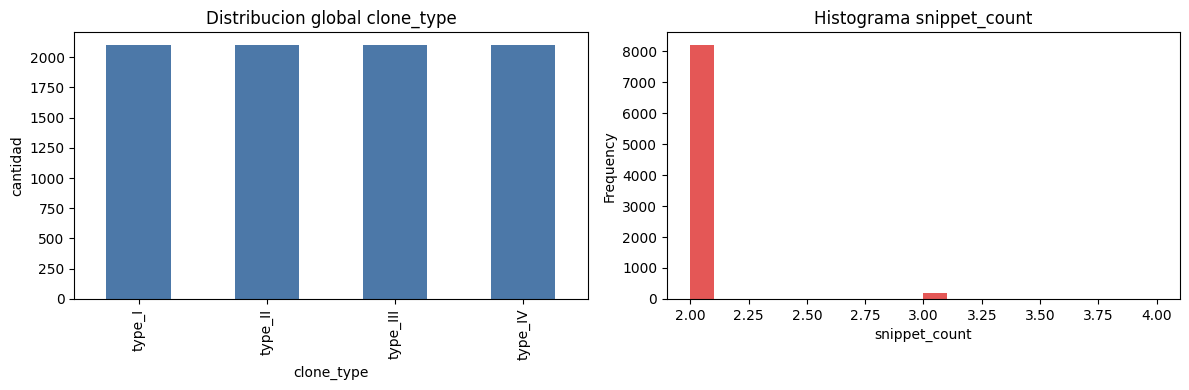

In [87]:

@dataclass
class ASTMetrics:
    total_nodes: float = 0.0
    depth: float = 0.0
    num_functions: float = 0.0
    num_loops: float = 0.0
    num_ifs: float = 0.0
    num_calls: float = 0.0
    num_imports: float = 0.0
    type_counts: dict[str, int] | None = None

    def __post_init__(self) -> None:
        # aqui inicializamos el diccionario de tipos si viene vacio
        if self.type_counts is None:
            self.type_counts = {}

    def to_feature_dict(self) -> dict[str, Any]:
        # aqui convertimos metricas ast al formato de features
        return {
            'ast_total_nodes': float(self.total_nodes),
            'ast_depth': float(self.depth),
            'ast_num_functions': float(self.num_functions),
            'ast_num_loops': float(self.num_loops),
            'ast_num_ifs': float(self.num_ifs),
            'ast_num_calls': float(self.num_calls),
            'ast_num_imports': float(self.num_imports),
            'ast_type_counts': dict(self.type_counts),
        }


class PythonASTStructuralVisitor:

    def __init__(self) -> None:
        # aqui iniciamos el visitor con metricas vacias
        self.metrics = ASTMetrics()

    def walk(self, tree: ast.AST) -> ASTMetrics:
        # aqui recorremos todo el arbol ast
        self.visit_node(tree, depth=1)
        return self.metrics

    def visit_node(self, node: ast.AST, depth: int) -> None:
        # aqui elegimos que visita usar para cada nodo
        self._register_common(node, depth)
        method_name = f"visit_{type(node).__name__}"
        visitor = getattr(self, method_name, self.generic_visit)
        visitor(node, depth)

    def _register_common(self, node: ast.AST, depth: int) -> None:
        # aqui contamos rasgos comunes para cada nodo
        self.metrics.total_nodes += 1.0
        self.metrics.depth = max(self.metrics.depth, float(depth))
        tname = type(node).__name__
        self.metrics.type_counts[tname] = self.metrics.type_counts.get(tname, 0) + 1

    def generic_visit(self, node: ast.AST, depth: int) -> None:
        # aqui visitamos hijos cuando no hay regla especial
        for child in ast.iter_child_nodes(node):
            self.visit_node(child, depth + 1)

    def visit_FunctionDef(self, node: ast.FunctionDef, depth: int) -> None:
        # aqui contamos funciones y seguimos recorriendo
        self.metrics.num_functions += 1.0
        self.generic_visit(node, depth)

    def visit_AsyncFunctionDef(self, node: ast.AsyncFunctionDef, depth: int) -> None:
        # aqui contamos funciones async y seguimos recorriendo
        self.metrics.num_functions += 1.0
        self.generic_visit(node, depth)

    def visit_For(self, node: ast.For, depth: int) -> None:
        # aqui contamos ciclos for y seguimos recorriendo
        self.metrics.num_loops += 1.0
        self.generic_visit(node, depth)

    def visit_AsyncFor(self, node: ast.AsyncFor, depth: int) -> None:
        # aqui contamos ciclos async for y seguimos recorriendo
        self.metrics.num_loops += 1.0
        self.generic_visit(node, depth)

    def visit_While(self, node: ast.While, depth: int) -> None:
        # aqui contamos ciclos while y seguimos recorriendo
        self.metrics.num_loops += 1.0
        self.generic_visit(node, depth)

    def visit_If(self, node: ast.If, depth: int) -> None:
        # aqui contamos if y seguimos recorriendo
        self.metrics.num_ifs += 1.0
        self.generic_visit(node, depth)

    def visit_Call(self, node: ast.Call, depth: int) -> None:
        # aqui contamos llamadas a funcion y seguimos recorriendo
        self.metrics.num_calls += 1.0
        self.generic_visit(node, depth)

    def visit_Import(self, node: ast.Import, depth: int) -> None:
        # aqui contamos imports y seguimos recorriendo
        self.metrics.num_imports += 1.0
        self.generic_visit(node, depth)

    def visit_ImportFrom(self, node: ast.ImportFrom, depth: int) -> None:
        # aqui contamos imports from y seguimos recorriendo
        self.metrics.num_imports += 1.0
        self.generic_visit(node, depth)


def _features_ast_vacias() -> dict[str, Any]:
    # aqui devolvemos features ast en cero cuando hay error
    return ASTMetrics().to_feature_dict()


def _diff_rel(a: float, b: float, eps: float = 1e-9) -> float:
    # aqui calculamos diferencia relativa entre dos valores
    denom = max(abs(float(a)), abs(float(b)), eps)
    return abs(float(a) - float(b)) / denom


def extraer_features_ast_snippet(codigo: str) -> dict[str, Any]:
    # aqui extraemos features ast de un snippet
    codigo_ok = codigo if codigo.strip() else 'pass'
    try:
        tree = ast.parse(codigo_ok)
    except SyntaxError:
        return _features_ast_vacias()

    visitor = PythonASTStructuralVisitor()
    metrics = visitor.walk(tree)
    return metrics.to_feature_dict()


def _jaccard_keys(d1: dict[str, int], d2: dict[str, int]) -> float:
    # aqui calculamos jaccard entre tipos de nodo
    k1, k2 = set(d1.keys()), set(d2.keys())
    if not k1 and not k2:
        return 1.0
    union = k1 | k2
    if not union:
        return 0.0
    return float(len(k1 & k2) / len(union))


def _weighted_overlap_counts(d1: dict[str, int], d2: dict[str, int]) -> float:
    # aqui calculamos overlap ponderado de tipos de nodo
    keys = set(d1.keys()) | set(d2.keys())
    if not keys:
        return 1.0
    inter = 0.0
    union = 0.0
    for key in keys:
        a = float(d1.get(key, 0))
        b = float(d2.get(key, 0))
        inter += min(a, b)
        union += max(a, b)
    if union == 0.0:
        return 0.0
    return inter / union


def construir_features_ast_par(df: pd.DataFrame) -> pd.DataFrame:
    # aqui construimos features ast por cada par
    rows = []
    for code_a, code_b in zip(df['code_a_clean'], df['code_b_clean']):
        fa = extraer_features_ast_snippet(code_a)
        fb = extraer_features_ast_snippet(code_b)

        n_a, n_b = fa['ast_total_nodes'], fb['ast_total_nodes']
        d_a, d_b = fa['ast_depth'], fb['ast_depth']
        f_a, f_b = fa['ast_num_functions'], fb['ast_num_functions']
        l_a, l_b = fa['ast_num_loops'], fb['ast_num_loops']
        i_a, i_b = fa['ast_num_ifs'], fb['ast_num_ifs']
        c_a, c_b = fa['ast_num_calls'], fb['ast_num_calls']
        im_a, im_b = fa['ast_num_imports'], fb['ast_num_imports']

        type_jaccard = _jaccard_keys(fa['ast_type_counts'], fb['ast_type_counts'])
        type_weighted = _weighted_overlap_counts(fa['ast_type_counts'], fb['ast_type_counts'])

        node_len_sim = (min(n_a, n_b) / max(n_a, n_b)) if max(n_a, n_b) > 0 else 1.0
        depth_sim = (min(d_a, d_b) / max(d_a, d_b)) if max(d_a, d_b) > 0 else 1.0
        structural_similarity = float(np.mean([node_len_sim, depth_sim, type_jaccard, type_weighted]))

        rows.append({
            'ast_nodes_a': n_a,
            'ast_nodes_b': n_b,
            'ast_nodes_diff': abs(n_a - n_b),
            'ast_nodes_diff_rel': _diff_rel(n_a, n_b),
            'ast_depth_a': d_a,
            'ast_depth_b': d_b,
            'ast_depth_diff': abs(d_a - d_b),
            'ast_depth_diff_rel': _diff_rel(d_a, d_b),
            'ast_functions_diff': abs(f_a - f_b),
            'ast_functions_diff_rel': _diff_rel(f_a, f_b),
            'ast_loops_diff': abs(l_a - l_b),
            'ast_loops_diff_rel': _diff_rel(l_a, l_b),
            'ast_ifs_diff': abs(i_a - i_b),
            'ast_ifs_diff_rel': _diff_rel(i_a, i_b),
            'ast_calls_diff': abs(c_a - c_b),
            'ast_calls_diff_rel': _diff_rel(c_a, c_b),
            'ast_imports_diff': abs(im_a - im_b),
            'ast_imports_diff_rel': _diff_rel(im_a, im_b),
            'ast_node_type_overlap': type_jaccard,
            'ast_node_type_weighted_overlap': type_weighted,
            'ast_structural_similarity': structural_similarity,
        })

    return pd.DataFrame(rows, index=df.index)


def construir_features_modelo_capa1(df: pd.DataFrame, vector: TfidfVectorizer, min_match_len: int = 3) -> pd.DataFrame:
    # aqui construimos la capa 1 lexical con baker
    x_base = construir_features_lexicas_base(df, vector)
    x_baker = construir_features_baker(df, min_match_len=min_match_len)
    return pd.concat([x_base, x_baker], axis=1)


def seleccionar_ast_reducido(x_ast: pd.DataFrame) -> pd.DataFrame:
    # aqui nos quedamos con las features ast mas utiles
    cols = [
        'ast_nodes_diff_rel',
        'ast_depth_diff_rel',
        'ast_functions_diff_rel',
        'ast_loops_diff_rel',
        'ast_ifs_diff_rel',
        'ast_calls_diff_rel',
        'ast_imports_diff_rel',
        'ast_node_type_overlap',
        'ast_structural_similarity',
    ]
    existentes = [c for c in cols if c in x_ast.columns]
    return x_ast[existentes].copy()


def construir_features_modelo(df: pd.DataFrame, vector: TfidfVectorizer, min_match_len: int = 3, ast_variant: str = 'none') -> pd.DataFrame:
    # aqui unimos features lexicas y baker
    x_lex = construir_features_modelo_capa1(df, vector, min_match_len=min_match_len)

    if ast_variant == 'none':
        return x_lex

    x_ast = construir_features_ast_par(df)

    if ast_variant == 'full':
        if 'baker_similarity' in x_lex.columns:
            x_ast['ast_x_baker_similarity'] = x_ast['ast_structural_similarity'] * x_lex['baker_similarity']
            x_ast['ast_type_overlap_x_baker'] = x_ast['ast_node_type_weighted_overlap'] * x_lex['baker_similarity']
        return pd.concat([x_lex, x_ast], axis=1)

    if ast_variant == 'reduced':
        x_ast_reducido = seleccionar_ast_reducido(x_ast)
        return pd.concat([x_lex, x_ast_reducido], axis=1)

    raise ValueError(f'ast_variant no soportado: {ast_variant}')


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
datos_preparados['clone_type'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#4C78A8')
axes[0].set_title('Distribucion global clone_type')
axes[0].set_xlabel('clone_type')
axes[0].set_ylabel('cantidad')

datos_preparados['snippet_count'].plot(kind='hist', bins=20, ax=axes[1], color='#E45756')
axes[1].set_title('Histograma snippet_count')
axes[1].set_xlabel('snippet_count')
plt.tight_layout()
plt.show()



## 6) split por `problem_id`


Estadisticas split del modelo:
{'split': 'test', 'rows': 1260, 'unique_groups': 315, 'class_distribution': {'type_I': 315, 'type_II': 315, 'type_III': 315, 'type_IV': 315}}
{'split': 'train', 'rows': 5880, 'unique_groups': 1470, 'class_distribution': {'type_I': 1470, 'type_II': 1470, 'type_III': 1470, 'type_IV': 1470}}
{'split': 'val', 'rows': 1260, 'unique_groups': 315, 'class_distribution': {'type_I': 315, 'type_II': 315, 'type_III': 315, 'type_IV': 315}}


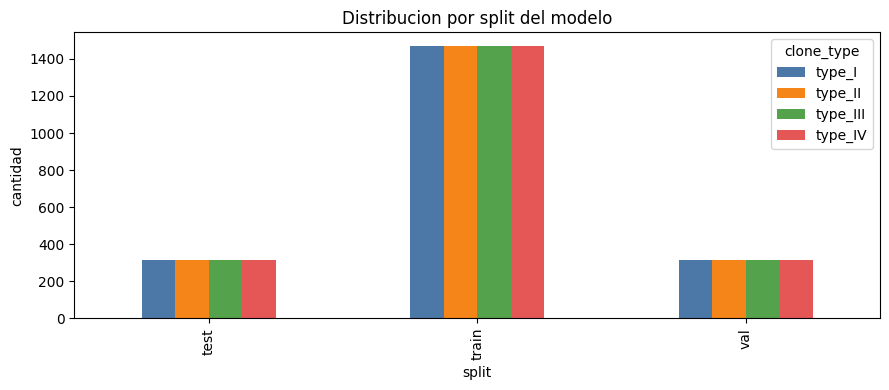

In [88]:
def split_por_grupo(df: pd.DataFrame, group_col: str, target_col: str, seed: int = 42, train_size: float = 0.7, val_size: float = 0.15, test_size: float = 0.15) -> ResultadoSplit:
    # aqui separamos train val test por problem_id
    proporcion_temp = val_size + test_size
    proporcion_test_rel = test_size / proporcion_temp

    gss_train = GroupShuffleSplit(n_splits=1, train_size=train_size, random_state=seed)
    idx_train_np, idx_temp_np = next(gss_train.split(df, y=df[target_col], groups=df[group_col]))

    df_temp = df.iloc[idx_temp_np]
    gss_temp = GroupShuffleSplit(n_splits=1, test_size=proporcion_test_rel, random_state=seed)
    idx_val_rel, idx_test_rel = next(gss_temp.split(df_temp, y=df_temp[target_col], groups=df_temp[group_col]))

    return ResultadoSplit(train_idx=df.index[idx_train_np], val_idx=df_temp.index[idx_val_rel], test_idx=df_temp.index[idx_test_rel])


def asignar_split(df, idx_train, idx_val, idx_test, nombre_columna='split'):
    # aqui etiquetamos cada fila con su split
    datos = df.copy()
    datos[nombre_columna] = 'unassigned'
    datos.loc[idx_train, nombre_columna] = 'train'
    datos.loc[idx_val, nombre_columna] = 'val'
    datos.loc[idx_test, nombre_columna] = 'test'
    return datos


def estadisticas_split(df: pd.DataFrame, split_col: str, target_col: str, group_col: str) -> list[dict[str, Any]]:
    # aqui revisamos distribucion por split
    resumen = []
    for nombre_split, df_split in df.groupby(split_col):
        conteos = df_split[target_col].value_counts().to_dict()
        resumen.append({'split': nombre_split, 'rows': int(len(df_split)), 'unique_groups': int(df_split[group_col].nunique()), 'class_distribution': {str(k): int(v) for k, v in conteos.items()}})
    return resumen


def balancear_train(df_train: pd.DataFrame, target_col: str, estrategia: str = 'none', seed: int = 42):
    # aqui balanceamos solo train para cuidar val y test
    conteos = df_train[target_col].value_counts()
    info = {'strategy': estrategia, 'target_col': target_col, 'rows_before': int(len(df_train)), 'class_distribution_before': {str(k): int(v) for k, v in conteos.items()}}

    if estrategia == 'none' or len(conteos) <= 1:
        info['rows_after'] = int(len(df_train))
        info['class_distribution_after'] = info['class_distribution_before']
        return df_train.copy(), info

    if estrategia == 'undersample':
        n_obj = int(conteos.min())
        rep = False
    elif estrategia == 'oversample':
        n_obj = int(conteos.max())
        rep = True
    else:
        info['rows_after'] = int(len(df_train))
        info['class_distribution_after'] = info['class_distribution_before']
        return df_train.copy(), info

    partes = []
    for clase in conteos.index.tolist():
        df_clase = df_train[df_train[target_col] == clase]
        partes.append(df_clase.sample(n=n_obj, replace=rep, random_state=seed))

    out = pd.concat(partes, axis=0).sample(frac=1.0, random_state=seed).copy()
    c2 = out[target_col].value_counts()
    info['rows_after'] = int(len(out))
    info['class_distribution_after'] = {str(k): int(v) for k, v in c2.items()}
    return out, info


split_modelo = split_por_grupo(
    df=datos_preparados,
    group_col='problem_id',
    target_col='clone_type',
    seed=SEED + 100,
    train_size=0.7,
    val_size=0.15,
    test_size=0.15,
)

datos_modelo = asignar_split(datos_preparados, split_modelo.train_idx, split_modelo.val_idx, split_modelo.test_idx)

print('Estadisticas split del modelo:')
stats_modelo = estadisticas_split(datos_modelo, 'split', 'clone_type', 'problem_id')
for fila in stats_modelo:
    print(fila)

conteos_split = datos_modelo.groupby(['split', 'clone_type']).size().unstack(fill_value=0)
conteos_split.plot(kind='bar', figsize=(9, 4), color=['#4C78A8', '#F58518', '#54A24B', '#E45756'])
plt.title('Distribucion por split del modelo')
plt.xlabel('split')
plt.ylabel('cantidad')
plt.tight_layout()
plt.show()



## 7) entrenamiento del modelo actual con random forest


<unknown>:2: SyntaxWarning: invalid escape sequence '\]'
<unknown>:2: SyntaxWarning: invalid escape sequence '\]'
<unknown>:2: SyntaxWarning: invalid escape sequence '\]'
<unknown>:2: SyntaxWarning: invalid escape sequence '\]'
<unknown>:2: SyntaxWarning: invalid escape sequence '\]'
<unknown>:2: SyntaxWarning: invalid escape sequence '\]'
<unknown>:2: SyntaxWarning: invalid escape sequence '\]'
<unknown>:2: SyntaxWarning: invalid escape sequence '\]'
<unknown>:2: SyntaxWarning: invalid escape sequence '\]'
<unknown>:2: SyntaxWarning: invalid escape sequence '\]'
<unknown>:2: SyntaxWarning: invalid escape sequence '\]'
<unknown>:2: SyntaxWarning: invalid escape sequence '\]'
<unknown>:2: SyntaxWarning: invalid escape sequence '\]'
<unknown>:2: SyntaxWarning: invalid escape sequence '\]'
<unknown>:2: SyntaxWarning: invalid escape sequence '\]'
<unknown>:2: SyntaxWarning: invalid escape sequence '\]'
<unknown>:2: SyntaxWarning: invalid escape sequence '\]'
<unknown>:2: SyntaxWarning: inv

--- Configuracion del modelo actual ---
modelo: random_forest
ast_variant: reduced
num_features: 28

--- Balanceo train ---
{'strategy': 'undersample', 'target_col': 'clone_type', 'rows_before': 5880, 'class_distribution_before': {'type_I': 1470, 'type_II': 1470, 'type_III': 1470, 'type_IV': 1470}, 'rows_after': 5880, 'class_distribution_after': {'type_IV': 1470, 'type_III': 1470, 'type_I': 1470, 'type_II': 1470}}

--- Metricas TEST ---
accuracy: 0.9421
precision_macro: 0.942
recall_macro: 0.9421
f1_macro: 0.942


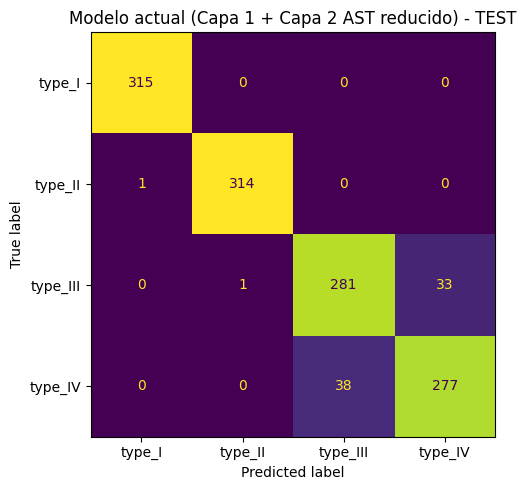

In [89]:
def evaluar_predicciones(y_true, y_pred, labels: list) -> dict[str, Any]:
    # aqui calculamos las metricas de evaluacion
    acc = accuracy_score(y_true, y_pred)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    p_w, r_w, f1_w, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
    reporte_dict = classification_report(y_true, y_pred, labels=labels, output_dict=True, zero_division=0)
    reporte_texto = classification_report(y_true, y_pred, labels=labels, zero_division=0)
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    return {
        'accuracy': float(acc),
        'precision_macro': float(p_macro),
        'recall_macro': float(r_macro),
        'f1_macro': float(f1_macro),
        'precision_weighted': float(p_w),
        'recall_weighted': float(r_w),
        'f1_weighted': float(f1_w),
        'confusion_matrix': cm.tolist(),
        'classification_report_dict': reporte_dict,
        'classification_report_text': reporte_texto,
    }


def entrenar_evaluar_modelo_actual(
    datos_task,
    columna_target,
    etiquetas,
    seed,
    estrategia_balanceo='none',
    min_match_len=3,
    ast_variant='reduced',
):
    # aqui entrenamos y evaluamos el modelo final
    train_raw = datos_task[datos_task['split'] == 'train'].copy()
    val = datos_task[datos_task['split'] == 'val'].copy()
    test = datos_task[datos_task['split'] == 'test'].copy()

    train_balanceado, info_balanceo = balancear_train(train_raw, columna_target, estrategia_balanceo, seed)

    vector_tfidf = ajustar_tfidf(train_balanceado)
    X_train = construir_features_modelo(train_balanceado, vector_tfidf, min_match_len=min_match_len, ast_variant=ast_variant)
    X_val = construir_features_modelo(val, vector_tfidf, min_match_len=min_match_len, ast_variant=ast_variant)
    X_test = construir_features_modelo(test, vector_tfidf, min_match_len=min_match_len, ast_variant=ast_variant)

    modelo = RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=2,
        class_weight='balanced_subsample',
        random_state=seed,
        n_jobs=-1,
    )
    modelo.fit(X_train, train_balanceado[columna_target])

    y_val = val[columna_target]
    y_test = test[columna_target]
    pred_val = modelo.predict(X_val)
    pred_test = modelo.predict(X_test)

    metricas_val = evaluar_predicciones(y_val, pred_val, labels=etiquetas)
    metricas_test = evaluar_predicciones(y_test, pred_test, labels=etiquetas)

    return {
        'info_balanceo': info_balanceo,
        'metricas_val': metricas_val,
        'metricas_test': metricas_test,
        'modelo': modelo,
        'feature_names': X_train.columns.tolist(),
        'num_features': int(X_train.shape[1]),
    }


def graficar_matriz_confusion(resultado: dict, etiquetas: list[str], titulo: str):
    # aqui graficamos la matriz de confusion de test
    cm = np.array(resultado['metricas_test']['confusion_matrix'])
    fig, ax = plt.subplots(1, 1, figsize=(6, 5))
    ConfusionMatrixDisplay(cm, display_labels=[str(x) for x in etiquetas]).plot(ax=ax, colorbar=False)
    ax.set_title(titulo)
    plt.tight_layout()
    plt.show()


etiquetas_modelo = sorted(datos_modelo['clone_type'].unique().tolist())

resultado_modelo_actual = entrenar_evaluar_modelo_actual(
    datos_task=datos_modelo,
    columna_target='clone_type',
    etiquetas=etiquetas_modelo,
    seed=SEED + 100,
    estrategia_balanceo=ESTRATEGIA_BALANCEO,
    min_match_len=MIN_MATCH_LEN_BAKER,
    ast_variant=AST_VARIANT_OFICIAL,
)

print('--- configuracion del modelo actual ---')
print('modelo:', MODELO_CLASIFICADOR)
print('ast_variant:', AST_VARIANT_OFICIAL)
print('num_features:', resultado_modelo_actual['num_features'])
print('')
print('--- balanceo train ---')
print(resultado_modelo_actual['info_balanceo'])
print('')
print('--- metricas test ---')
print('accuracy:', round(resultado_modelo_actual['metricas_test']['accuracy'], 4))
print('precision_macro:', round(resultado_modelo_actual['metricas_test']['precision_macro'], 4))
print('recall_macro:', round(resultado_modelo_actual['metricas_test']['recall_macro'], 4))
print('f1_macro:', round(resultado_modelo_actual['metricas_test']['f1_macro'], 4))

graficar_matriz_confusion(
    resultado_modelo_actual,
    etiquetas_modelo,
    'Modelo actual (Capa 1 + Capa 2 AST reducido) - TEST',
)



## 8) evaluacion del modelo actual


In [90]:
resumen_modelo_actual = pd.DataFrame([
    {
        'modelo': MODELO_CLASIFICADOR,
        'ast_variant': AST_VARIANT_OFICIAL,
        'num_features': resultado_modelo_actual['num_features'],
        'accuracy_val': resultado_modelo_actual['metricas_val']['accuracy'],
        'precision_macro_val': resultado_modelo_actual['metricas_val']['precision_macro'],
        'recall_macro_val': resultado_modelo_actual['metricas_val']['recall_macro'],
        'f1_macro_val': resultado_modelo_actual['metricas_val']['f1_macro'],
        'accuracy_test': resultado_modelo_actual['metricas_test']['accuracy'],
        'precision_macro_test': resultado_modelo_actual['metricas_test']['precision_macro'],
        'recall_macro_test': resultado_modelo_actual['metricas_test']['recall_macro'],
        'f1_macro_test': resultado_modelo_actual['metricas_test']['f1_macro'],
    }
])

print('resumen del modelo actual')
display(resumen_modelo_actual)

rep = resultado_modelo_actual['metricas_test']['classification_report_dict']
rows_cls = []
for lbl in etiquetas_modelo:
    rows_cls.append({
        'label': lbl,
        'precision_test': rep[lbl]['precision'],
        'recall_test': rep[lbl]['recall'],
        'f1_test': rep[lbl]['f1-score'],
        'support_test': rep[lbl]['support'],
    })

metricas_por_clase = pd.DataFrame(rows_cls).sort_values('label')
print('metricas por clase en test')
display(metricas_por_clase)

print('foco en type_iii y type_iv')
display(metricas_por_clase[metricas_por_clase['label'].isin(['type_III', 'type_IV'])])



Resumen del modelo actual:


,modelo,ast_variant,num_features,accuracy_val,precision_macro_val,recall_macro_val,f1_macro_val,accuracy_test,precision_macro_test,recall_macro_test,f1_macro_test
0,random_forest,reduced,28,0.942063,0.942148,0.942063,0.942003,0.942063,0.942022,0.942063,0.942019


Metricas por clase (TEST):


,label,precision_test,recall_test,f1_test,support_test
0,type_I,0.996835,1.000000,0.998415,315.0
1,type_II,0.996825,0.996825,0.996825,315.0
2,type_III,0.880878,0.892063,0.886435,315.0
3,type_IV,0.893548,0.879365,0.886400,315.0


Foco en type_III y type_IV:


,label,precision_test,recall_test,f1_test,support_test
2,type_III,0.880878,0.892063,0.886435,315.0
3,type_IV,0.893548,0.879365,0.886400,315.0


## 9) interpretacion de resultados

en esta version oficial usamos

- capa 1 lexical + baker
- capa 2 ast reducido
- random forest

nos enfocamos en metricas globales y en `type_iii` y `type_iv`


## 10) siguiente paso del proyecto

con esta base lista en dos capas despues podemos agregar

1. capa de contexto
2. capa de embeddings


## 11) reflexion final del modelo y resultados obtenidos

en esta etapa dejamos una version estable del modelo con dos capas

- capa 1 lexical con baker
- capa 2 ast reducido
- random forest como clasificador

estos fueron los resultados obtenidos en test

- accuracy 0.9421
- precision macro 0.9420
- recall macro 0.9421
- f1 macro 0.9420

en clases complejas vimos

- type_iii f1 0.8864 y recall 0.8921
- type_iv f1 0.8864 y recall 0.8794

con esto vemos que ya tenemos una base fuerte y clara para seguir con la siguiente capa de contexto y despues embeddings
